# 6.4 Data gaps & Thermal transients

Throughout the mission the spacecraft will change its orientation due to multiple reasons (as we will discuss in the next subsection) and thus leave **data gaps** in the otherwise continuous observations. The motion and/or orientation of the spacecraft will cause the components of each camera (TOU, CCDs, FEE, etc.) to undergo a temperature change. This will in turn result in a temporarily increase of electron counts. This phenomena is known as a **thermal transient**.
 
In Simple Aperture Photometry (SAP) a thermal transient event manifests in a positive flux jump followed by a "reheating" process seen as an exponentially decrease in flux back to the count level as before the event. The main cause of thermal trasients is due to the temperature dependece of the CCD gain (and to second order on a slightly change of the camera focus). The reheating timescale depends on the duration of the interruption, i.e. typically maximally up to a few days. By default PlatoSim does not account for thermal transients, hence, we show how to do this in the following.

### Setup notebook

In [467]:
# Alow changes to the PlatoSim code outside this notebook
%load_ext autoreload
%autoreload 2

# To interact with the plot use
%matplotlib notebook

The autoreload extension is already loaded. To reload it, use:
  %reload_ext autoreload


### Imports

In [470]:
import os
import numpy as np
import matplotlib.pyplot as plt

# PlatoSim
import platosim.noise      as ns
from platosim.simulation   import Simulation
from platosim.simfile      import SimFile
from platosim.matplotlibrc import setup_notebook
setup_notebook()

### Global parameters

In [471]:
outputDir = os.getcwd()
day2sec   = 86400.

### Functions

In [472]:
def run(sim, tdur, exampleNr):
    
    # Turn off saving 
    sim.turnOffAllOutput()

    # Control HDF5
    sim["ControlHDF5Content/GroupByExposure"]    = True
    sim["ControlHDF5Content/WritePixelMaps"]     = True
    sim["ControlHDF5Content/WriteStarPositions"] = True
    sim["ControlHDF5Content/WriteCosmics"]       = True

    # Let's simulate 20 days
    sim["ObservingParameters/NumExposures"] = int(tdur*day2sec/25.)

    # Select subfield size and location
    sim["SubField/NumColumns"]      = 6
    sim["SubField/NumRows"]         = 6
    sim["SubField/ZeroPointRow"]    = 1000
    sim["SubField/ZeroPointColumn"] = 1000

    # Automatic photometry file creation
    starID = [0]
    photometryFile = outputDir + f"/photometry_{exampleNr}.txt"
    sim.createPhotometryFile(starID, photometryFile)

    # Define catalogue
    row = np.array([3.0]) + sim["SubField/ZeroPointRow"]
    col = np.array([3.0]) + sim["SubField/ZeroPointColumn"]
    mag = np.array([10.0])

    # Automatic catalogue file creation
    starcatFile = outputDir + f"/starcat_{exampleNr}.txt"
    sim.createStarCatalogFileFromPixelCoordinates(row, col, mag, starID, starcatFile)

    # Run the simulation
    return sim.run(removeOutputFile=True, executionTime=True)

---
## 6.4.1 - Simple example
---

In [473]:
# Set up a Simulation object
sim = Simulation("output_example1", outputDir=outputDir)

We first show how you can model thermal transients using PlatoSim's build-in functionality called `noise.temperatureTransients()`. This function models each transient event given an array of time points (`time`), start time(s) of the transient event(s) (`t0`), and the corresponding duration of the event(s) (`td`) . Let's model three events of different durations for a 8 day simulation:

<IPython.core.display.Javascript object>


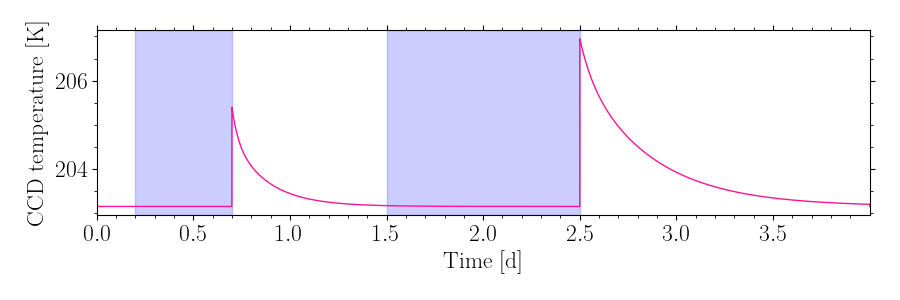

In [479]:
tdur = 4
time = np.arange(0, int(day2sec * tdur), 25.)
t0 = np.array([0.2, 1.5]) * day2sec
td = np.array([0.5, 1.0]) * day2sec

# Fetch CCD temperature zero-point and generate model
tempCCD0 = sim["CCD/NominalOperatingTemperature"]
tempCCD  = ns.temperatureTransients(time, t0, td, tempCCD=tempCCD0, plot=True)

Note that the resultant model do not include data gaps, which is done on purpose to secure that PlatoSim uses a proper (linear interpolation) when simulating data inside gaps. Given the above model we can now use `sim.createDetectorTemperatureFile()` to apply this model in our simulation:

In [480]:
ccdFileName = outputDir + "/ccdtemp_example1.txt"
sim.createDetectorTemperatureFile(time, tempCCD, ccdFileName)

Like any file creation with PlatoSim, the CCD temperature module above automatically sets the newly created file in the YAML tree. Alternatively, you can alter these entries with:

In [481]:
sim["CCD/Temperature"]         = "FromFile"
sim["CCD/TemperatureFileName"] = ccdFileName

We now use the pre-built function for this notebook called `run()` to simulate and extract the photometry for a single target star:

In [482]:
# Run simulation
f = run(sim, tdur, 'example1')

Execution time : 0:00:43.500257 [hh:mm:ss]


<IPython.core.display.Javascript object>


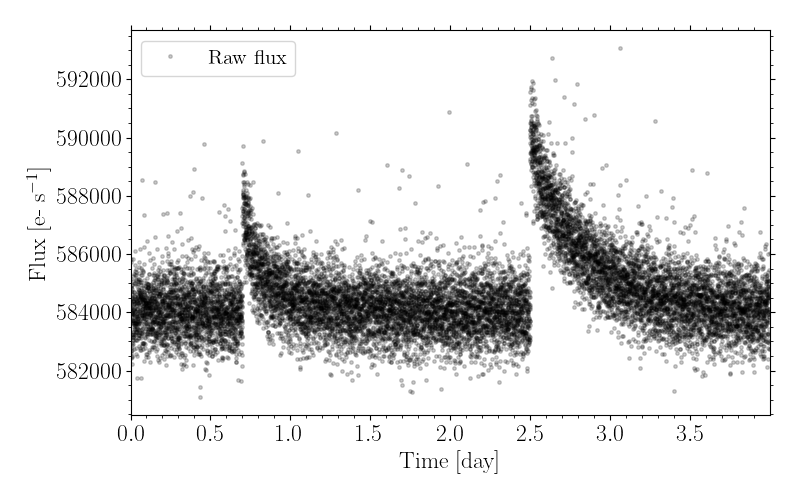

In [483]:
# Plot light curve
fig, ax = f.plotLightCurve(0, timeUnit='day', fluxUnit='e/s');

We can now remove the data in the gaps:

In [494]:
df = f.getLightCurve(0)
# df.drop()

---
## 6.4.2 - Advanced example
---

Given the knowledge of previous space mission similar to PLATO (e.g. the *Kepler* mission) we consider the following time gaps:

  - Quarterly rolls
  - Monthly data donlinks
  - Loss of fine guidance
  - Save mode events

**Quarterly rolls** introduce a time gap of 1-2 days happening every three months (hence four times in a year). These are are needed in order to align the spacecraft's solar panels towards the Sun. Note that the PES called PRE takes into account for the error in every pointing from quarter to quarter. 

**Montly data downlinks** is needed during the mission. During these events the spacecraft changed its orientation once a month to point at Earth and downlink the last month of data. This caused a gap in the time series data, as the spacecraft can not collect while it was downlinking.

**Loss of fine guidance and coarse pointing events** which results in a lower photometric precision. Typically these cadences are not suggested for use in photometry. Since these event do not introduce thermal transients in the light curve, they can simply be removed after the simulations have been generated by the user. 

**Safe modes** are another type of thermal transient that appears in Kepler data. A safe mode occured when the telescope temporarily shut off operation due to an unexpected event, usually caused by an issue with the detector electronics.

Taking advantage of the knowledge from the *Kepler* mission, below we show how you easily can model the above mentioned time gaps using the utility `noise.getDataGaps()`. This function takes an array of time points and return a pandas data frame indicating each event (with boolean values), the start time of each event, and their duration. Let's simulate 8 mission quarters (720 days): 

<IPython.core.display.Javascript object>


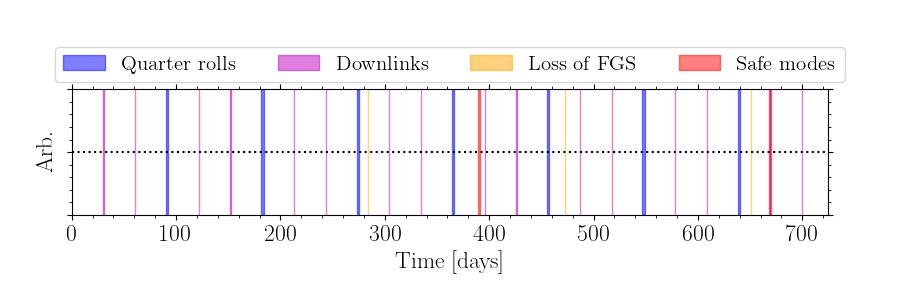

In [491]:
tdur = 720
time = np.arange(0, int(86400 * tdur), 25)

# Create a time series with data gaps
df, t0, td = ns.getDataGaps(time, plot=True)

Note that safe mode events are secured not to overlap with quarterly roll or downlink events (as it would be unphysical to have transient events within a data gap). Now the output of `noise.getDataGaps()` can directly be parsed to `noise.temperatureTransients()`:

<IPython.core.display.Javascript object>


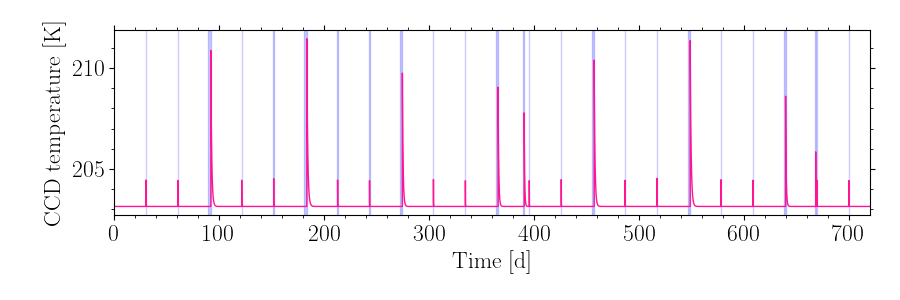

In [493]:
tempCCD = ns.temperatureTransients(df.time, t0, td, tempCCD=tempCCD0, plot=True)

As mentioned tote that loss of fine guidance events do not result in a transient event (since the pointing does not change). We will not run a full 90 day simulation here, but you can generate and set the above CCD temperature file to the YAML tree and run the simulation as done in the previous example.